In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!curl -O $data
df = pd.read_csv('car_fuel_efficiency_2026.csv')


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  5412k      0 --:--:-- --:--:-- --:--:-- 5441k


In [2]:
df.isnull().sum()
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

**Cleaning text data**. Column names and the values in string columns are converted to lowercase with spaces replaced by underscores. This makes column names easier to use in code and ensures categorical values that differ only in capitalization or spacing are treated as the same category.

In [3]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.dtypes[df.dtypes == 'str']
string_cols = list(df.dtypes[df.dtypes == 'str'].index)
string_cols
for columns in string_cols: 
    df[columns] = df[columns].str.lower().str.replace(" ","_")

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
50%         30.000000
90%         33.800000
95%         34.905000
99%         36.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

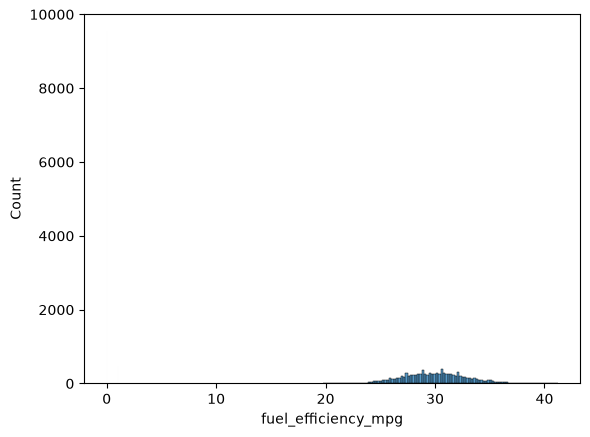

In [4]:
## Preparing the Dataset
df_exercise = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df_exercise.head()

## Exploratory Data Analysis
df_exercise['fuel_efficiency_mpg'].unique()[:5]
#df_exercise['fuel_efficiency_mpg'].nunique
sns.histplot(df_exercise.fuel_efficiency_mpg,bins=100)
## indentifying long tail
sns.histplot(df_exercise.fuel_efficiency_mpg > 35,bins=100)
df_exercise.fuel_efficiency_mpg.describe(percentiles=[.5, .9, .95, .99])


In [5]:
#Q1 - Column with missing values
df_exercise.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [6]:
#Q2 - What's the median (50% percentile) for variable 'horsepower'?
df_exercise.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

**Prepare and split the dataset**
For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Option 1: fill with 0
df_train_zero = df_train.fillna({'fuel_efficiency_mpg': 0})
df_val_zero = df_val.fillna({'fuel_efficiency_mpg': 0})
df_test_zero = df_test.fillna({'fuel_efficiency_mpg': 0})

# Option 2: fill with the training-set mean
hp_mean = df_train.horsepower.mean()
df_train_mean = df_train.fillna({'fuel_efficiency_mpg': hp_mean})
df_val_mean = df_val.fillna({'fuel_efficiency_mpg': hp_mean})
df_test_mean = df_test.fillna({'fuel_efficiency_mpg': hp_mean})

In [8]:
df_train.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
## VALIDATION FRAMEWORK

y_train_zero = df_train_zero.fuel_efficiency_mpg.values
y_val_zero = df_val_zero.fuel_efficiency_mpg.values
y_test_zero = df_test_zero.fuel_efficiency_mpg.values

y_train_mean = df_train_mean.fuel_efficiency_mpg.values
y_val_mean = df_val_mean.fuel_efficiency_mpg.values
y_test_mean = df_test_mean.fuel_efficiency_mpg.values

In [10]:
## Converting Dataframe into an Array
## Selecting a primary set of features to include in v1 of the regression model 

base = ['engine_displacement', 'num_cylinders', 'vehicle_weight', 'acceleration','horsepower']

def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train_zero = prepare_X(df_train_zero)
X_train_mean = prepare_X(df_train_mean)
X_train_zero, X_train_mean

(array([[1900. ,    5. , 3790. ,   20.3,  239. ],
        [2000. ,    6. , 4380. ,   21.8,  224. ],
        [2330. ,    6. , 4090. ,   17.8,  286. ],
        ...,
        [2240. ,    6. , 4190. ,   17.2,  255. ],
        [2430. ,    6. , 4280. ,   18.4,  254. ],
        [2390. ,    6. , 4220. ,   19.6,  266. ]], shape=(6000, 5)),
 array([[1900. ,    5. , 3790. ,   20.3,  239. ],
        [2000. ,    6. , 4380. ,   21.8,  224. ],
        [2330. ,    6. , 4090. ,   17.8,  286. ],
        ...,
        [2240. ,    6. , 4190. ,   17.2,  255. ],
        [2430. ,    6. , 4280. ,   18.4,  254. ],
        [2390. ,    6. , 4220. ,   19.6,  266. ]], shape=(6000, 5)))

In [11]:
def train_linear_regression(X,y):
    
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    X_T = np.linalg.matrix_transpose(X)
    X_TX = X_T @ X
    X_TX_INV = np.linalg.inv(X_TX)
    #X_TX.dot(X_TX_INV).round()
    (X_TX @ X_TX_INV).round()
    w = X_TX_INV.dot(X_T).dot(y)
    return w[0], w[1:]

w0_0, w_0 = train_linear_regression(X_train_zero,y_train_zero)
w0_mean, w_mean = train_linear_regression(X_train_mean,y_train_mean)

y_pred_0 = w0_0 + X_train_zero.dot(w_0)
y_pred_mean = w0_mean + X_train_mean.dot(w_mean)
y_pred_0, y_pred_mean


(array([32.77762716, 30.15827553, 30.94870835, ..., 30.59584394,
        29.72260771, 30.11311851], shape=(6000,)),
 array([32.77762716, 30.15827553, 30.94870835, ..., 30.59584394,
        29.72260771, 30.11311851], shape=(6000,)))

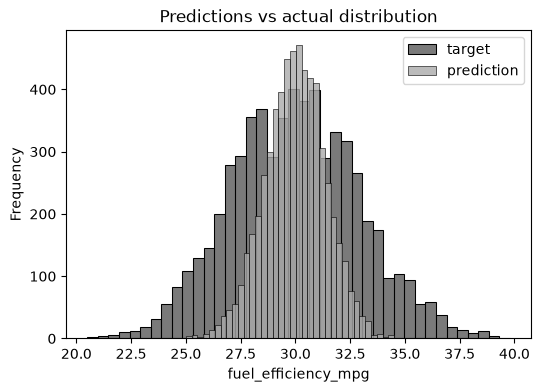

In [12]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train_zero, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred_0, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('fuel_efficiency_mpg')
plt.title('Predictions vs actual distribution')

plt.show()

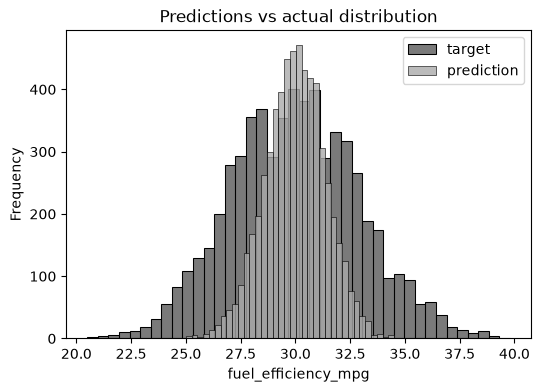

In [13]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train_mean, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred_mean, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('fuel_efficiency_mpg')
plt.title('Predictions vs actual distribution')

plt.show()

In [14]:
## Calculating RMSE
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [15]:
rmse(y_train_mean,y_pred_mean) ##Mean is better
rmse(y_train_zero,y_pred_0)

np.float64(2.5910527003586914)

In [16]:
##Training model with a regularized linear regression

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

w0_0, w_0 = train_linear_regression_reg(X_train_zero,y_train_zero)
w0_mean, w_mean = train_linear_regression_reg(X_train_mean,y_train_mean)

y_pred_0 = w0_0 + X_train_zero.dot(w_0)
y_pred_mean = w0_mean + X_train_mean.dot(w_mean)
y_pred_0, y_pred_mean


(array([32.77762716, 30.15827553, 30.94870835, ..., 30.59584394,
        29.72260771, 30.11311851], shape=(6000,)),
 array([32.77762716, 30.15827553, 30.94870835, ..., 30.59584394,
        29.72260771, 30.11311851], shape=(6000,)))

In [17]:
def rmse_reg(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
reg_rmse_score = {}

for r in r_values: 
    w0, w = train_linear_regression_reg(X_train_mean,y_train_mean,r=r)
    y_pred_reg = w0 + X_train_mean.dot(w)
    reg_rmse_score[r] = round(rmse_reg(y_train_mean,y_pred_reg),4)
reg_rmse_score

{0: np.float64(2.5911),
 0.01: np.float64(2.5911),
 0.1: np.float64(2.5911),
 1: np.float64(2.5947),
 5: np.float64(2.6552),
 10: np.float64(2.7677),
 100: np.float64(3.5946)}

**Testing different Seed Values**
Disclosure: I used Claude Code for assistance with Question 5 & 6

In [18]:
def split_and_fill(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    hp_mean = df_train.horsepower.mean()

    return {
        'zero': {
            'train': df_train.fillna({'fuel_efficiency_mpg': 0}),
            'val':   df_val.fillna({'fuel_efficiency_mpg': 0}),
            'test':  df_test.fillna({'fuel_efficiency_mpg': 0}),
        },
        'mean': {
            'train': df_train.fillna({'fuel_efficiency_mpg': hp_mean}),
            'val':   df_val.fillna({'fuel_efficiency_mpg': hp_mean}),
            'test':  df_test.fillna({'fuel_efficiency_mpg': hp_mean}),
        },
    }

seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
splits = {seed: split_and_fill(df, seed) for seed in seed_values}

In [19]:
scores = {}
for seed in seed_values:
    d = splits[seed]['zero']

    X_train = prepare_X(d['train'])
    y_train = d['train'].fuel_efficiency_mpg.values
    X_val = prepare_X(d['val'])
    y_val = d['val'].fuel_efficiency_mpg.values

    w0, w = train_linear_regression_reg(X_train, y_train, r=0)
    y_pred = w0 + X_val.dot(w)
    scores[seed] = rmse(y_val, y_pred)

scores, round(np.std(list(scores.values())), 3)

({0: np.float64(2.6536370594693093),
  1: np.float64(2.588929720423266),
  2: np.float64(2.526149505279096),
  3: np.float64(2.598889267847473),
  4: np.float64(2.5364920742428674),
  5: np.float64(2.6426660691833965),
  6: np.float64(2.643768742391611),
  7: np.float64(2.5780276314497494),
  8: np.float64(2.596070278923095),
  9: np.float64(2.568498914659051)},
 np.float64(0.042))

**Question 6**

In [20]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Option 1: fill with 0
df_train_zero = df_train.fillna({'fuel_efficiency_mpg': 0})
df_val_zero = df_val.fillna({'fuel_efficiency_mpg': 0})
df_test_zero = df_test.fillna({'fuel_efficiency_mpg': 0})

# Option 2: fill with the training-set mean
hp_mean = df_train.horsepower.mean()
df_train_mean = df_train.fillna({'fuel_efficiency_mpg': hp_mean})
df_val_mean = df_val.fillna({'fuel_efficiency_mpg': hp_mean})
df_test_mean = df_test.fillna({'fuel_efficiency_mpg': hp_mean})

In [21]:
# Combine the training and validation sets into one larger training set.
# Model choices (fill method, r value) were already made using the validation
# set, so its data can now go toward training the final model.
# reset_index(drop=True) gives the combined dataframe a clean 0..n-1 index
# instead of the shuffled indices carried over from the original split.
df_full_train = pd.concat([df_train_zero, df_val_zero]).reset_index(drop=True)

# Build the feature matrix from the combined data.
# prepare_X selects the columns in `base` and converts them to a NumPy array.
X_full_train = prepare_X(df_full_train)

# Target values: the actual fuel efficiency the model learns to predict.
y_full_train = df_full_train.fuel_efficiency_mpg.values

# Prepare the test set the same way as the training data.
# The test set was not used for training or for any modeling decisions,
# so its score is an unbiased estimate of performance on new cars.
X_test = prepare_X(df_test_zero)          # inputs the model predicts from
y_test = df_test_zero.fuel_efficiency_mpg.values   # true mpg to compare against

# Train the regularized linear regression on the combined data.
# r=0.001 adds a small penalty on large weights (ridge regularization).
# w0 is the bias (intercept); w is the array of weights, one per feature.
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# Predict mpg for each test car: bias + (features x weights).
y_pred = w0 + X_test.dot(w)

# RMSE: the typical size of a prediction error, in mpg.
# Lower is better.
rmse(y_test, y_pred)

np.float64(2.631740829921767)